# 土地銀行數位種子人才發展計劃

> 機器學習概念與行銷模型應用

[郭耀仁](https://hahow.in/@tonykuoyj) | <yaojenkuo@ntu.edu.tw>

## 目錄

- 機器學習基礎概念（P.3）
- 基礎分類模型與基礎回歸模型 - 信用卡行銷模型案例、信用貸款行銷模型案例（P.17）
- 個案討論：使用 Python 機器學習析模組實踐「核准 vs. 婉拒」的信用卡、信用貸款分類模型、使用 Python 機器學習析模組實踐「核准額度」的信用卡、信用貸款迴歸模型（P.34）
- 如何使用 Python 模組快速建立基礎分群模型、推薦模型與信用評分卡模型（P.37）
- 實作：檢視各小組題目中機器學習模型的需求，盤點資料來源、需求欄位，以 mock data 測試能否順利完成，簡報預演（P.41）

## 機器學習基礎概念

## 機器學習的三個要素、一個但書

> A computer program is said to learn from experience E with respect to some class of tasks T and performance measure P if its performance at tasks in T, as measured by P, improves with experience E.

來源：[Machine Learning, Tom Mitchell, McGraw Hill, 1997](http://www.cs.cmu.edu/~tom/mlbook.html)

## 傳統透過電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/3pojPXW.png?1)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定規則 $w$ 以及資料 $X$，我們就可以定義出函數 $f$ 生成答案 $y$

\begin{equation}
y = f(X;w) = Xw
\end{equation}

## 以機器學習的電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/YunyLd7.png)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定答案 $y$ 以及資料 $X$，機器學習的電腦程式在最小化損失函數 $J$ 的前提下生成規則 $w$，進而獲得預測 $\hat{y}$

\begin{equation}
\text{choose} \; w \in \{w^1, w^2, ..., w^n\} \\
\text{where} \; w \; \text{minimizes} \; J(w) \\
\text{subject to} \; \hat{y} = h(X; w) = Xw \\
\text{where} \; J(w) \; \text{measures the loss between} \; y \; \text{and} \; \hat{y} \\
\end{equation}

## 預測數值時最常見的損失函數 $J$

最小化均方誤差（Mean squared error）。

\begin{align}
\operatorname*{arg\,min}_w \;  J(w) =  \frac{1}{m} \sum_i^m (y_i - \hat{y_i})^2
\end{align}

## 預測類別時最常見的損失函數 $J$

最小化預測錯誤個數。

\begin{align}
\operatorname*{arg\,min}_w \; J(w) = \sum_j n(E_j) \text{ where } E_j \; \text{represents the occurrence of } y_j \neq \hat{y_j}
\end{align}

## 機器學習的資料表達：特徵矩陣與目標陣列

- 外型 `(m, n)` 的特徵矩陣 $X$
- 外型 `(m,)` 的目標陣列 $y$

In [1]:
import matplotlib.pyplot as plt

def plot_X_y():
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.axis('equal')
    # Draw features matrix
    ax.vlines(range(6), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=0, xmax=5, lw=1)
    font_prop = dict(size=12, family='monospace')
    ax.text(-1, -1, "Feature Matrix ($X$)", size=14)
    ax.text(0.1, -0.3, r'n_features $\longrightarrow$', **font_prop)
    ax.text(-0.1, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    # Draw labels vector
    ax.vlines(range(8, 10), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=8, xmax=9, lw=1)
    ax.text(7, -1, "Target Array ($y$)", size=14)
    ax.text(7.9, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    ax.set_ylim(10, -2)
    plt.show()

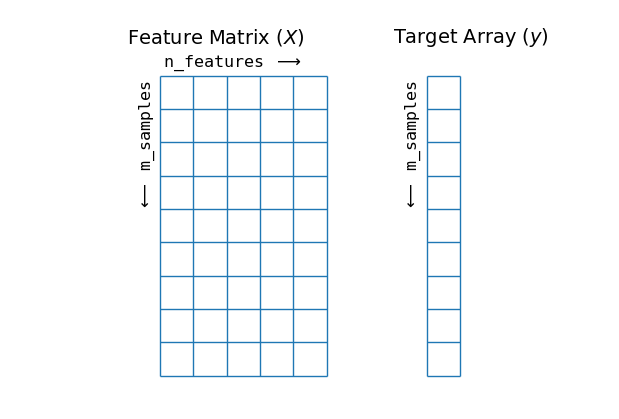

In [2]:
# 來源：<https://jakevdp.github.io/PythonDataScienceHandbook>
plot_X_y()

## 如何從 `DataFrame` 中擷取特徵矩陣與目標陣列

In [3]:
import pandas as pd

csv_url = "https://raw.githubusercontent.com/datainpoint/classroom-landbank-2026/refs/heads/main/data/player_stats.csv"
player_stats = pd.read_csv(csv_url) # import data
print(type(player_stats))
print(player_stats.shape)

<class 'pandas.core.frame.DataFrame'>
(503, 50)


## `player_stats` NBA 球員的基本資訊與生涯攻守數據

In [4]:
player_stats.head()

,firstName,lastName,temporaryDisplayName,personId,teamId,jersey,isActive,pos,heightFeet,heightInches,...,ftm,fta,pFouls,points,gamesPlayed,gamesStarted,plusMinus,min,dd2,td3
0,Precious,Achiuwa,"Achiuwa, Precious",1630173,1610612748,5.0,True,F,6,8,...,56.0,110.0,91.0,304.0,61.0,4.0,-116.0,737.0,3.0,0.0
1,Steven,Adams,"Adams, Steven",203500,1610612740,12.0,True,C,6,11,...,936.0,1708.0,1497.0,5629.0,588.0,524.0,1638.0,15812.0,125.0,1.0
2,Bam,Adebayo,"Adebayo, Bam",1628389,1610612748,13.0,True,C-F,6,9,...,842.0,1141.0,668.0,3549.0,287.0,183.0,258.0,7840.0,91.0,5.0
3,Ty-Shon,Alexander,"Alexander, Ty-Shon",1630234,1610612756,0.0,True,G,6,3,...,1.0,2.0,2.0,9.0,15.0,0.0,-8.0,47.0,0.0,0.0
4,Nickeil,Alexander-Walker,"Alexander-Walker, Nickeil",1629638,1610612740,6.0,True,G,6,6,...,73.0,103.0,145.0,775.0,93.0,14.0,-105.0,1597.0,0.0,0.0


In [5]:
X = player_stats[["apg", "rpg"]].values # select 2 columns
y = player_stats["pos"].values          # select 1 column
print(X.shape)
print(y.shape)

(503, 2)
(503,)


In [6]:
X = player_stats["heightMeters"].values.reshape(-1, 1) # select 1 column
y = player_stats["weightKilograms"].values             # select 1 column
print(X.shape)
print(y.shape)

(503, 1)
(503,)


## 基礎分類模型與基礎回歸模型 - 信用卡行銷模型案例、信用貸款行銷模型案例

## 什麼是 Scikit-Learn

> Scikit-learn 是 Python 機器學習的第三方模組，透過它可以進行監督式以及非監督式學習，提供了模型訓練、資料預處理、模型選擇以及模型評估等功能。

來源：<https://scikit-learn.org>

## 根據說明文件的範例載入

多數時候我們使用 Scikit-Learn 中的特定類別或函數，因此以 `from sklearn import FUNCTION/CLASS` 載入特定類別或函數，而非 `import sklearn`

來源：<https://scikit-learn.org/stable/getting_started.html>

## 為什麼選擇 Scikit-Learn

- 簡潔、一致且設計良善的應用程式介面設計，只要理解基礎用法和語法，就能延伸切換到其他的演算法或模型。
- 文件撰寫完整而豐富。
- 維護良善。

## Scikit-Learn 應用程式介面設計原則

1. 一致性。
2. 可檢查性。
3. 不擴增新類別。
4. 可組合性。
5. 合理預設參數。

## 轉換器與預測器是 Scikit-Learn 所創造最重要的兩種類別

1. **轉換器：用來預處理資料。**
2. 預測器：用來訓練模型、生成規則 $w$

## 使用 Scikit-Learn 轉換器的標準步驟

1. 準備欲轉換的特徵矩陣 $X$ 或目標陣列 $y$
2. 建立轉換器類別的物件。
3. 將欲轉換的特徵矩陣 $X$ 或目標陣列 $y$ 輸入 `object.fit_transform()`
4. 檢查轉換結果。

## 使用 Scikit-Learn 轉換器 `PolynomialFeatures`

生成一個指定次方數的特徵多項式矩陣。

In [7]:
from sklearn.preprocessing import PolynomialFeatures

X = player_stats["heightMeters"].values.reshape(-1, 1) # step 1
polynomial_features = PolynomialFeatures()             # step 2
X_transformed = polynomial_features.fit_transform(X)   # step 3
print(X_transformed[:5])                               # step 4

[[1.     2.03   4.1209]
 [1.     2.11   4.4521]
 [1.     2.06   4.2436]
 [1.     1.9    3.61  ]
 [1.     1.98   3.9204]]


## 使用 Scikit-Learn 轉換器 `StandardScaler`

生成一個經過 z-score 標準化的特徵矩陣。

\begin{equation}
z = \frac{x - \mu}{\sigma}
\end{equation}

In [8]:
from sklearn.preprocessing import StandardScaler

X = player_stats["heightMeters"].values.reshape(-1, 1) # step 1
standard_scaler = StandardScaler()                     # step 2
X_transformed = standard_scaler.fit_transform(X)       # step 3
print(X_transformed[:5])                               # step 4

[[ 0.48558003]
 [ 1.42770829]
 [ 0.83887812]
 [-1.04537841]
 [-0.10325014]]


## 轉換器與預測器是 Scikit-Learn 所創造最重要的兩種類別

1. 轉換器：用來預處理資料。
2. **預測器：用來訓練模型、生成規則 $w$**

## 使用 Scikit-Learn 預測器的標準步驟

1. 準備欲訓練預測的特徵矩陣 $X$  與目標陣列 $y$
2. 切割訓練與驗證資料。
3. 建立預測器類別的物件。
4. 將訓練特徵矩陣 $X^{train}$ 與目標陣列 $y^{train}$ 輸入 `predictor.fit()`
5. 將驗證特徵矩陣 $X^{valid}$ 輸入 `predictor.predict()` 獲得 $\hat{y}^{valid}$
6. 比對 $\hat{y}^{valid}$ 與 $y^{valid}$ 之間的差異

## 關於切割訓練與驗證資料

- 訓練資料：具有實際值或標籤的已實現歷史資料。
- 驗證資料：具有實際值或標籤的已實現歷史資料，但是在使用上偽裝成不具有實際值或標籤的待預測資料。
- 使用 `sklearn.model_selection` 的 `train_test_split()` 函數。
    - `test_size` 驗證資料比例。
    - `random_state` 觀測值洗牌的隨機種子。

In [9]:
from sklearn.model_selection import train_test_split

## 使用 Scikit-Learn 預測器 `LinearRegression`

- 線性迴歸模型。
- 數值預測器：NBA 球員的體重。

In [10]:
from sklearn.linear_model import LinearRegression

X = player_stats["heightMeters"].values.reshape(-1, 1)                       # step 1
y = player_stats["weightKilograms"].values                                   # step 1
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42) # step 2
linear_regression = LinearRegression()                                       # step 3
linear_regression.fit(X_train, y_train)                                      # step 4
y_hat = linear_regression.predict(X_valid)                                   # step 5
m = y_valid.size                                                             # step 6
mean_squared_error = ((y_valid - y_hat)**2).sum()/m                          # step 6

## 使用 Scikit-Learn 預測器 `LogisticRegression`

- 羅吉斯迴歸模型。
- 類別預測器（分類器）：NBA 球員的鋒衛位置。

In [11]:
from sklearn.linear_model import LogisticRegression

pos_dict = {value: index for index, value in enumerate(player_stats["pos"].unique())}
X = player_stats[["apg", "rpg"]].values       # step 1
y = player_stats["pos"].map(pos_dict).values  # step 1
print(player_stats["pos"].unique())
print(pos_dict)
print(y[:5])

['F' 'C' 'C-F' 'G' 'F-G' 'G-F' 'F-C']
{'F': 0, 'C': 1, 'C-F': 2, 'G': 3, 'F-G': 4, 'G-F': 5, 'F-C': 6}
[0 1 2 3 3]


In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42) # step 2
logistic_regression = LogisticRegression()                                   # step 3
logistic_regression.fit(X_train, y_train)                                    # step 4
y_hat = logistic_regression.predict(X_valid)                                 # step 5
number_of_misclassification = (y_valid != y_hat).sum()                       # step 6
print(number_of_misclassification)                                           # step 6

54


## 複習：Scikit-Learn 應用程式介面設計原則

- 一致性。
    - 每個轉換器類別都有 `fit_transform()` 方法。
    - 每個預測器類別都有 `fit()` 與 `predict()` 方法。
- 合理預設參數。
    - 每個轉換器、預測器都可以用預設參數建立物件。

## 複習：Scikit-Learn 應用程式介面設計原則（續）

可檢查性：每個轉換器或預測器都有屬性讓使用者檢視轉換或預測的規則。

In [13]:
print(polynomial_features.degree)
print(standard_scaler.mean_)
print(standard_scaler.scale_)
print(linear_regression.intercept_)
print(linear_regression.coef_)

2
[1.9887674]
[0.08491413]
-99.05995720054044
[99.1199283]


## 個案討論：使用 Python 機器學習析模組實踐「核准 vs. 婉拒」的信用卡、信用貸款分類模型、使用 Python 機器學習析模組實踐「核准額度」的信用卡、信用貸款迴歸模型

## 使用 Python 機器學習析模組實踐「核准 vs. 婉拒」的信用卡、信用貸款分類模型

透過 `ucimlrepo` 下載資料集。

```bash
!pip install ucimlrepo
```

```python
from ucimlrepo import fetch_ucirepo

credit_approval = fetch_ucirepo(id=27)
X = credit_approval.data.features
y = credit_approval.data.targets
```

## 使用 Python 機器學習析模組實踐「核准額度」的信用卡、信用貸款迴歸模型

透過 `kagglehub` 下載資料集。


```bash
!pip install kagglehub
```

```python
import kagglehub

path = kagglehub.dataset_download("whenamancodes/credit-card-customers-prediction")
print(path)
```

## 如何使用 Python 模組快速建立基礎分群模型、推薦模型與信用評分卡模型

## 使用 Python 模組快速建立基礎分群模型

透過 `ucimlrepo` 下載資料集。

```bash
!pip install ucimlrepo
```

```python
credit_approval = fetch_ucirepo(id=27)
X = credit_approval.data.features
```

## 使用 Python 模組快速建立推薦模型

透過 `Surprise`(AS in Simple Python RecommendatIon System Engine) 模組。

```bash
!pip install "numpy<2"
!pip install surprise
```

```python
from surprise import Dataset

data = Dataset.load_builtin('ml-100k')
```

## 使用 Python 模組快速建立信用評分卡模型

透過 `scorecardpy` 模組。

```bash
!pip install scorecardpy
```

```python
import scorecardpy as sc

dat = sc.germancredit()
```

## 實作：檢視各小組題目中機器學習模型的需求，盤點資料來源、需求欄位，以 mock data 測試能否順利完成，簡報預演